#**Classification**

**Tasks:**

*Load the dataset. (from Scikit-learn built-in datasets)*

*Explore the features and target classes.*

*Split the data into training and testing sets.*

*Train a Logistic Regression model.*

*Make predictions.*

*Evaluate the model using the metrics above.*

In [7]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='class')


In [12]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [11]:
y.head()

,class
0,0
1,0
2,0
3,0
4,0


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [14]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 178 entries, 0 to 177
Series name: class
Non-Null Count  Dtype
--------------  -----
178 non-null    int64
dtypes: int64(1)
memory usage: 1.5 KB


In [15]:
X.duplicated().sum()

np.int64(0)

In [18]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(142, 13)
(36, 13)
(142,)
(36,)


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)



LogisticRegression()

In [24]:
predictions = model.predict(X_test)

print(y_test , predictions)

19     0
45     0
140    2
30     0
67     1
16     0
119    1
174    2
109    1
141    2
24     0
150    2
41     0
118    1
15     0
111    1
113    1
82     1
9      0
114    1
18     0
66     1
60     1
169    2
171    2
164    2
117    1
65     1
90     1
55     0
29     0
128    1
145    2
31     0
12     0
42     0
Name: class, dtype: int64 [0 0 2 0 1 0 1 2 1 2 0 2 0 1 0 1 1 1 0 1 0 1 1 2 2 2 1 1 1 0 0 1 2 0 0 0]


In [25]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

accuracy = accuracy_score(y_test,predictions)

precision = precision_score(y_test , predictions , average = 'weighted')

recall = recall_score(y_test , predictions , average = 'weighted')

f1 = f1_score(y_test , predictions, average='weighted')

In [27]:
print("Accuracy : " , accuracy)
print("\n-------------------------------------\n")
print("Precision : " , precision)
print("\n-------------------------------------\n")
print("Recall : " , recall)
print("\n-------------------------------------\n")
print("F1 Score : " , f1)

Accuracy :  1.0

-------------------------------------

Precision :  1.0

-------------------------------------

Recall :  1.0

-------------------------------------

F1 Score :  1.0


In [30]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(y_test, predictions)

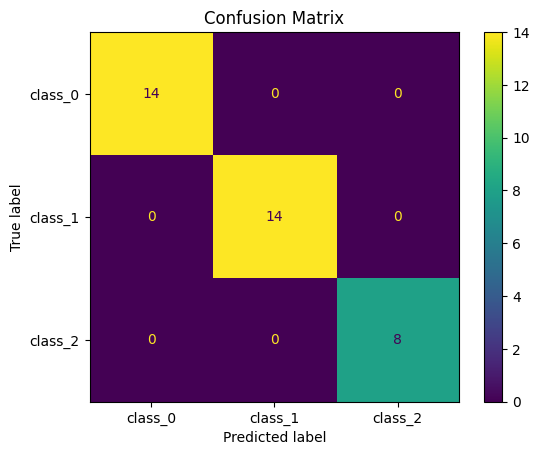

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=wine.target_names)

display.plot()
plt.title("Confusion Matrix")
plt.show()